# World Happiness Report 2023 — EDA

Dataset source: [World Happiness Report 2023 (Kaggle)](https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023/data)

Each row represents one country. The **Ladder score** (the target/outcome variable) comes from the Gallup World Poll, where respondents rate their current life on a scale from 0 (worst possible life) to 10 (best possible life) — the "Cantril Ladder". The remaining columns are factors used to explain differences in that score across countries.

## Column dictionary

| Column | Description |
|---|---|
| `Country name` | Name of the country surveyed. |
| `Ladder score` | Average Cantril Ladder (life evaluation) score for the country, on a 0–10 scale. This is the happiness score itself. |
| `Standard error of ladder score` | Standard error of the estimated ladder score, reflecting survey sampling uncertainty. |
| `upperwhisker` | Upper bound of the 95% confidence interval for the ladder score (`Ladder score` + ~1.96 × standard error). |
| `lowerwhisker` | Lower bound of the 95% confidence interval for the ladder score. |
| `Logged GDP per capita` | Natural log of GDP per capita (PPP-adjusted), used to dampen the effect of large income outliers. |
| `Social support` | National average of binary (0/1) responses to "If you were in trouble, do you have relatives or friends you can count on?" |
| `Healthy life expectancy` | Healthy life expectancy at birth, in years, sourced from WHO/World Bank estimates. |
| `Freedom to make life choices` | National average of binary responses to "Are you satisfied with your freedom to choose what you do with your life?" |
| `Generosity` | Residual of the national average response to "Have you donated money to a charity in the past month?", adjusted for GDP per capita. |
| `Perceptions of corruption` | National average of binary responses about whether corruption is widespread in government and businesses. |
| `Ladder score in Dystopia` | Fixed reference constant (score of the hypothetical "Dystopia", a country with the world's lowest values for each factor). Used as a baseline for the decomposition below. |
| `Explained by: Log GDP per capita` | Estimated contribution of GDP per capita to the country's ladder score, from the regression decomposition. |
| `Explained by: Social support` | Estimated contribution of social support to the ladder score. |
| `Explained by: Healthy life expectancy` | Estimated contribution of healthy life expectancy to the ladder score. |
| `Explained by: Freedom to make life choices` | Estimated contribution of freedom to the ladder score. |
| `Explained by: Generosity` | Estimated contribution of generosity to the ladder score. |
| `Explained by: Perceptions of corruption` | Estimated contribution of (low) corruption perception to the ladder score. |
| `Dystopia + residual` | Sum of the Dystopia baseline and the unexplained residual, so that `Ladder score ≈ Dystopia + residual + sum of all "Explained by" columns`. |

> Note: the six `Explained by: *` columns are outputs of an OLS regression that decomposes each country's ladder score into additive parts. They are **not** raw survey values — the raw values are the plain-named columns (`Logged GDP per capita`, `Social support`, etc.).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('WHR2023.csv')

In [3]:

data

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),3.207,0.095,3.394,3.020,7.007,0.652,55.375,0.664,0.086,0.834,1.778,0.531,0.784,0.105,0.375,0.183,0.068,1.162
133,Zimbabwe,3.204,0.061,3.323,3.084,7.641,0.690,54.050,0.654,-0.046,0.766,1.778,0.758,0.881,0.069,0.363,0.112,0.117,0.905
134,Sierra Leone,3.138,0.082,3.299,2.976,7.394,0.555,54.900,0.660,0.105,0.858,1.778,0.670,0.540,0.092,0.371,0.193,0.051,1.221
135,Lebanon,2.392,0.044,2.479,2.305,9.478,0.530,66.149,0.474,-0.141,0.891,1.778,1.417,0.476,0.398,0.123,0.061,0.027,-0.110


## 1. Dataset shape and structure

In [4]:
print(f"Rows, columns: {data.shape}")
data.info()

Rows, columns: (137, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 19 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                137 non-null    object 
 1   Ladder score                                137 non-null    float64
 2   Standard error of ladder score              137 non-null    float64
 3   upperwhisker                                137 non-null    float64
 4   lowerwhisker                                137 non-null    float64
 5   Logged GDP per capita                       137 non-null    float64
 6   Social support                              137 non-null    float64
 7   Healthy life expectancy                     136 non-null    float64
 8   Freedom to make life choices                137 non-null    float64
 9   Generosity                                  137 non-null    fl

## 2. Missing values and summary statistics

In [5]:
missing = data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values.")

data.describe()

Missing values per column:
Healthy life expectancy                  1
Explained by: Healthy life expectancy    1
Dystopia + residual                      1
dtype: int64


,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,136.000000,137.000000,137.000000,137.000000,1.370000e+02,137.000000,137.000000,136.000000,137.000000,137.000000,137.000000,136.000000
mean,5.539796,0.064715,5.666526,5.412971,9.449796,0.799073,64.967632,0.787394,0.022431,0.725401,1.778000e+00,1.406985,1.156212,0.366176,0.540000,0.148474,0.145898,1.777838
std,1.139929,0.023031,1.117421,1.163724,1.207302,0.129222,5.750390,0.112371,0.141707,0.176956,2.897173e-15,0.432963,0.326322,0.156691,0.149501,0.076053,0.126723,0.504390
min,1.859000,0.029000,1.923000,1.795000,5.527000,0.341000,51.530000,0.382000,-0.254000,0.146000,1.778000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.110000
25%,4.724000,0.047000,4.980000,4.496000,8.591000,0.722000,60.648500,0.724000,-0.074000,0.668000,1.778000e+00,1.099000,0.962000,0.248500,0.455000,0.097000,0.060000,1.555250
50%,5.684000,0.060000,5.797000,5.529000,9.567000,0.827000,65.837500,0.801000,0.001000,0.774000,1.778000e+00,1.449000,1.227000,0.389500,0.557000,0.137000,0.111000,1.848500
75%,6.334000,0.077000,6.441000,6.243000,10.540000,0.896000,69.412500,0.874000,0.117000,0.846000,1.778000e+00,1.798000,1.401000,0.487500,0.656000,0.199000,0.187000,2.078750
max,7.804000,0.147000,7.875000,7.733000,11.660000,0.983000,77.280000,0.961000,0.531000,0.929000,1.778000e+00,2.200000,1.620000,0.702000,0.772000,0.422000,0.561000,2.955000


## 3. Distribution of the Ladder score and key predictors

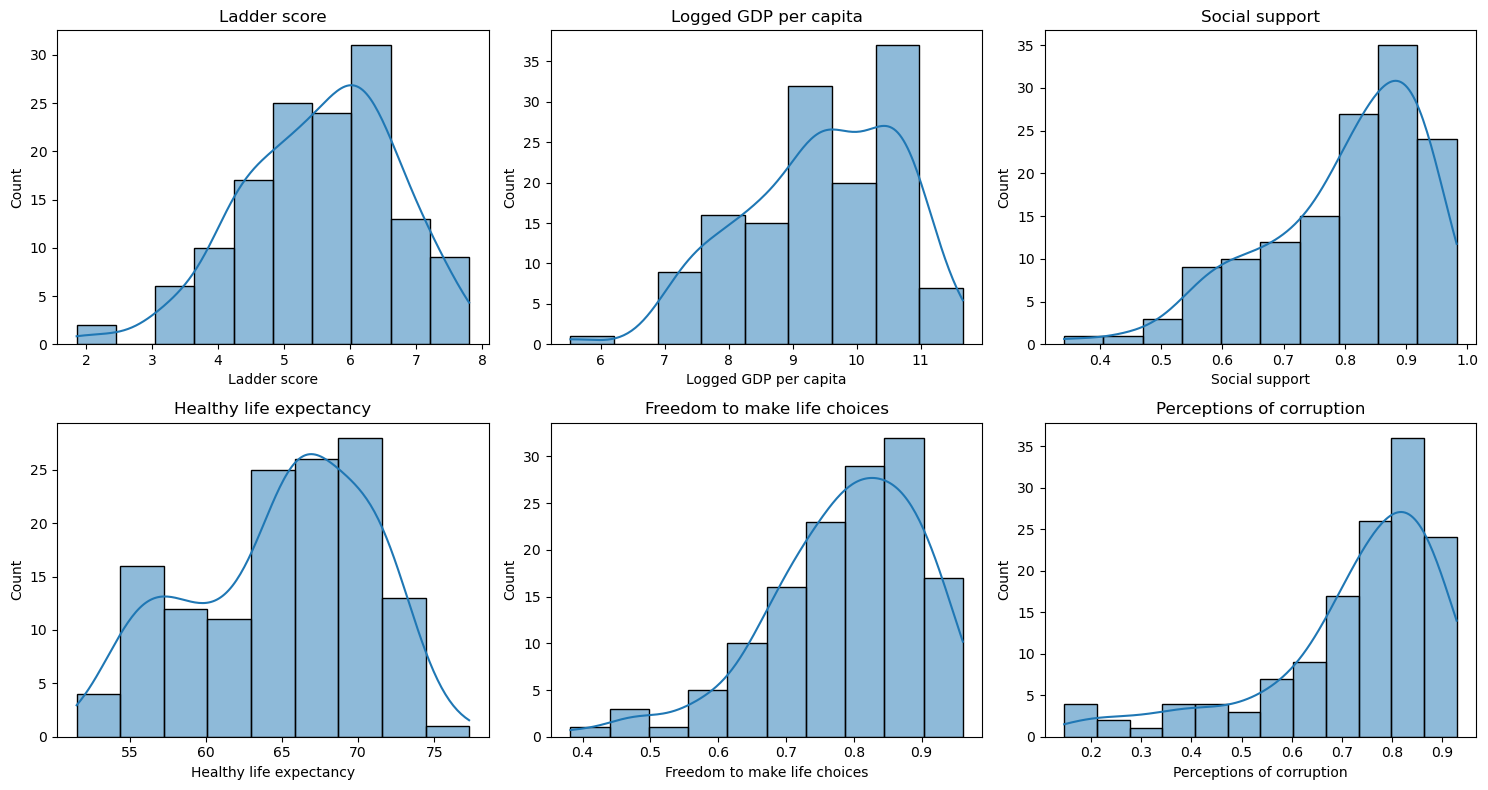

In [6]:
cols_to_plot = [
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Correlation between Ladder score and the explanatory factors

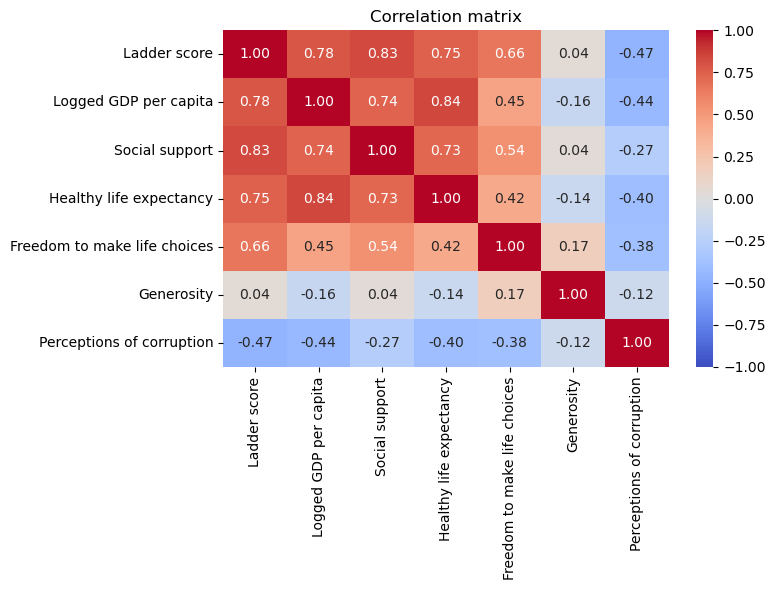

In [7]:
factor_cols = [
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption",
]

corr = data[factor_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## 5. Ladder score vs. GDP per capita

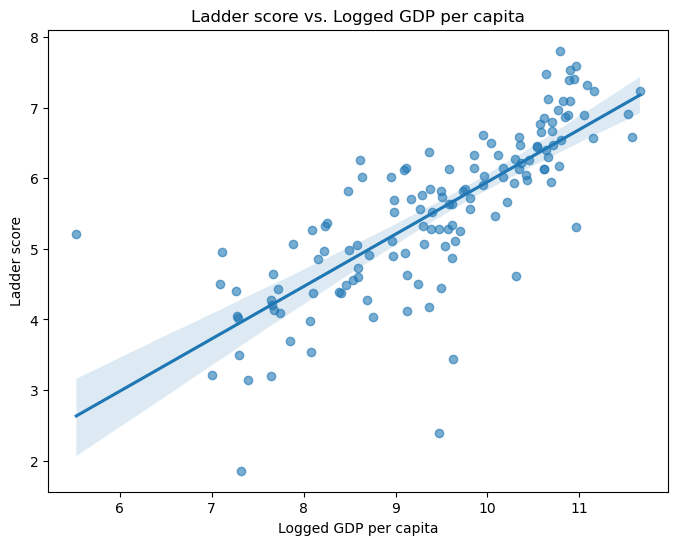

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(data=data, x="Logged GDP per capita", y="Ladder score", scatter_kws={"alpha": 0.6})
plt.title("Ladder score vs. Logged GDP per capita")
plt.show()

## 6. Happiest and least happy countries

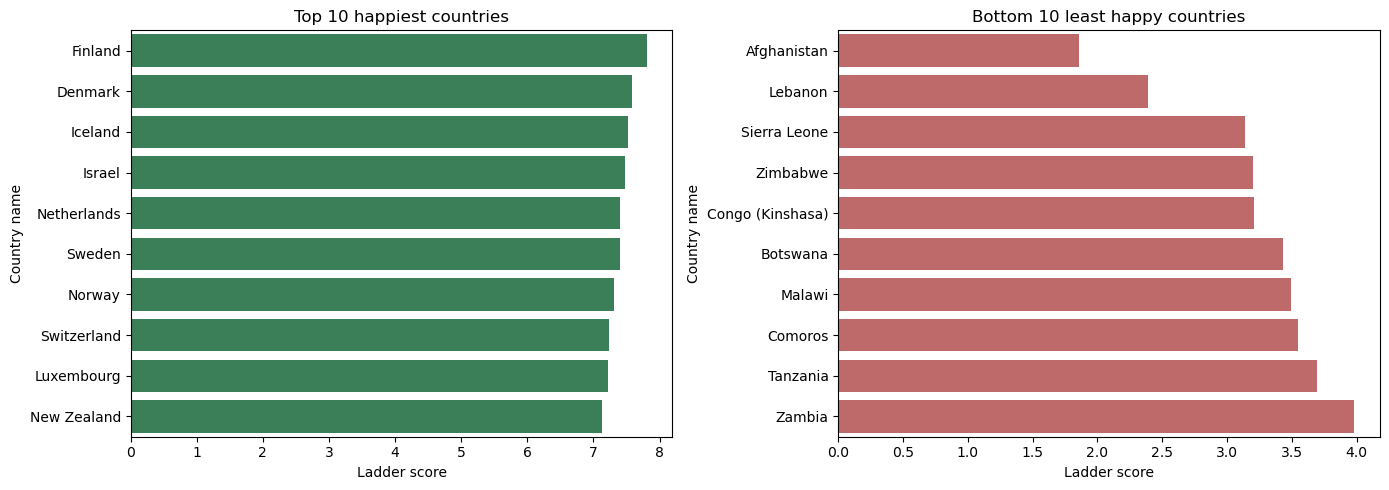

In [9]:
top10 = data.nlargest(10, "Ladder score")[["Country name", "Ladder score"]]
bottom10 = data.nsmallest(10, "Ladder score")[["Country name", "Ladder score"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top10, y="Country name", x="Ladder score", ax=axes[0], color="seagreen")
axes[0].set_title("Top 10 happiest countries")
sns.barplot(data=bottom10, y="Country name", x="Ladder score", ax=axes[1], color="indianred")
axes[1].set_title("Bottom 10 least happy countries")
plt.tight_layout()
plt.show()

## Takeaways

- The Ladder score is left-skewed toward lower values overall, but roughly bell-shaped in the mid-range where most countries fall.
- `Logged GDP per capita`, `Social support`, and `Healthy life expectancy` show the strongest positive correlation with the Ladder score, consistent with the official WHR findings.
- `Generosity` and `Perceptions of corruption` correlate much more weakly with happiness than the other factors.
- Wealthier countries (higher logged GDP per capita) tend to report higher happiness, but the relationship flattens at the top end — extra income matters less once basic needs are met.
- The gap between the top 10 and bottom 10 countries is large (several points on a 0–10 scale), driven mainly by differences in GDP, social support, and life expectancy rather than generosity or corruption perception.